# Eda on Students_Performance

In [200]:
#importing libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import scipy.stats as stats
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error,mean_absolute_percentage_error,mean_squared_error,root_mean_squared_error

In [201]:
#Load Dataset
df = pd.read_csv(r"D:\Machine_learning\DataSet\StudentsPerformance_1.csv",header=0)

In [202]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   gender                       957 non-null    object 
 1   race/ethnicity               1000 non-null   object 
 2   parental level of education  957 non-null    object 
 3   lunch                        1000 non-null   object 
 4   test preparation course      1000 non-null   object 
 5   math score                   972 non-null    float64
 6   reading score                973 non-null    float64
 7   writing score                974 non-null    float64
dtypes: float64(3), object(5)
memory usage: 62.6+ KB


In [203]:
df.index = range(1,1001)

In [204]:
df.head(10)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
1,female,group B,bachelor's degree,standard,none,72.0,72.0,74.0
2,female,group C,some college,standard,completed,NaN,90.0,88.0
3,NaN,group B,master's degree,standard,none,90.0,95.0,93.0
4,male,group A,NaN,free/reduced,none,47.0,57.0,44.0
5,male,group C,some college,standard,none,76.0,78.0,75.0
6,female,group B,associate's degree,standard,none,71.0,NaN,78.0
7,female,group B,some college,standard,completed,88.0,95.0,92.0
8,male,group B,some college,free/reduced,none,40.0,43.0,39.0
9,NaN,group D,high school,free/reduced,completed,64.0,64.0,67.0
10,female,group B,high school,free/reduced,none,38.0,60.0,50.0


In [205]:
df.tail(10)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
991,male,group E,high school,free/reduced,completed,NaN,81.0,75.0
992,female,group B,some high school,standard,completed,65.0,82.0,NaN
993,NaN,group D,associate's degree,free/reduced,none,55.0,76.0,76.0
994,female,group D,NaN,free/reduced,none,62.0,72.0,74.0
995,male,group A,high school,standard,none,63.0,63.0,62.0
996,female,group E,master's degree,standard,completed,88.0,99.0,95.0
997,male,group C,high school,free/reduced,none,62.0,NaN,55.0
998,female,group C,high school,free/reduced,completed,59.0,71.0,65.0
999,female,group D,some college,standard,completed,NaN,78.0,77.0
1000,female,group D,some college,free/reduced,none,77.0,86.0,86.0


In [206]:
df.describe()

,math score,reading score,writing score
count,972.000000,973.000000,974.000000
mean,66.141975,69.235355,67.990760
std,15.164135,14.537277,15.254906
min,0.000000,17.000000,10.000000
25%,57.000000,59.000000,57.000000
50%,66.000000,70.000000,69.000000
75%,77.000000,79.000000,79.000000
max,100.000000,100.000000,100.000000


In [207]:
df.isnull().any()

gender                          True
race/ethnicity                 False
parental level of education     True
lunch                          False
test preparation course        False
math score                      True
reading score                   True
writing score                   True
dtype: bool

In [208]:
df.isna().sum()

gender                         43
race/ethnicity                  0
parental level of education    43
lunch                           0
test preparation course         0
math score                     28
reading score                  27
writing score                  26
dtype: int64

In [209]:
col=df[['gender','parental level of education']]
for i in col:
    df[i]=df[i].fillna('unknown')

In [210]:
df.isnull().any()

gender                         False
race/ethnicity                 False
parental level of education    False
lunch                          False
test preparation course        False
math score                      True
reading score                   True
writing score                   True
dtype: bool

In [211]:
df.duplicated()

1       False
2       False
3       False
4       False
5       False
        ...  
996     False
997     False
998     False
999     False
1000    False
Length: 1000, dtype: bool

In [212]:
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

In [213]:
col1=df[['math score','reading score','writing score']]

In [214]:
df['math score']=df['math score'].fillna(df['math score'].median())
df['reading score']=df['reading score'].fillna(df['reading score'].median())
df['writing score']=df['writing score'].fillna(df['writing score'].median())

In [215]:
df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
1,female,group B,bachelor's degree,standard,none,72.0,72.0,74.0
2,female,group C,some college,standard,completed,66.0,90.0,88.0
3,unknown,group B,master's degree,standard,none,90.0,95.0,93.0
4,male,group A,unknown,free/reduced,none,47.0,57.0,44.0
5,male,group C,some college,standard,none,76.0,78.0,75.0
...,...,...,...,...,...,...,...,...
996,female,group E,master's degree,standard,completed,88.0,99.0,95.0
997,male,group C,high school,free/reduced,none,62.0,70.0,55.0
998,female,group C,high school,free/reduced,completed,59.0,71.0,65.0
999,female,group D,some college,standard,completed,66.0,78.0,77.0


In [216]:
df['total_score']=df[['math score','reading score','writing score']].sum(axis=1)

In [217]:
df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total_score
1,female,group B,bachelor's degree,standard,none,72.0,72.0,74.0,218.0
2,female,group C,some college,standard,completed,66.0,90.0,88.0,244.0
3,unknown,group B,master's degree,standard,none,90.0,95.0,93.0,278.0
4,male,group A,unknown,free/reduced,none,47.0,57.0,44.0,148.0
5,male,group C,some college,standard,none,76.0,78.0,75.0,229.0
...,...,...,...,...,...,...,...,...,...
996,female,group E,master's degree,standard,completed,88.0,99.0,95.0,282.0
997,male,group C,high school,free/reduced,none,62.0,70.0,55.0,187.0
998,female,group C,high school,free/reduced,completed,59.0,71.0,65.0,195.0
999,female,group D,some college,standard,completed,66.0,78.0,77.0,221.0


<Axes: xlabel='total_score', ylabel='Count'>

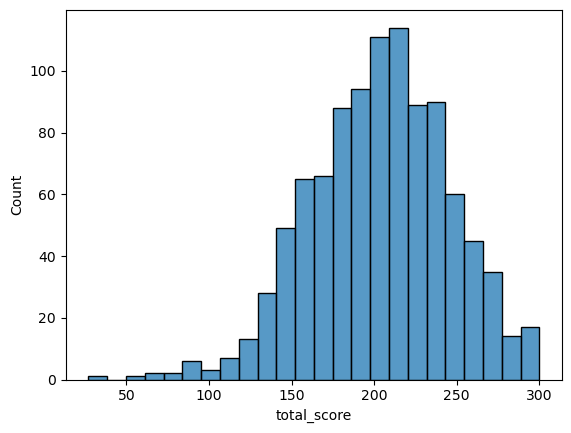

In [218]:
sns.histplot(data=df.total_score)

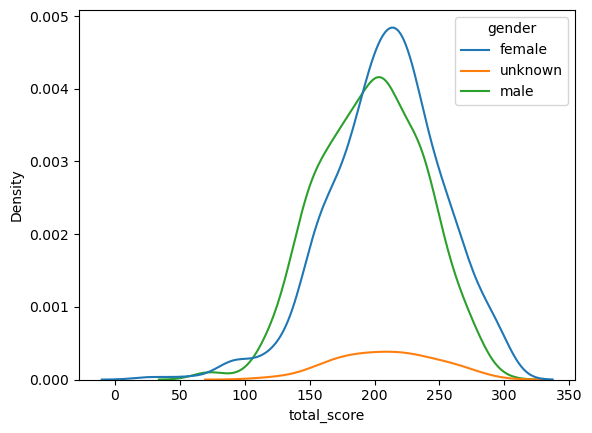

In [219]:
sns.kdeplot(data=df, x='total_score',hue='gender')
plt.show()


<Axes: xlabel='total_score'>

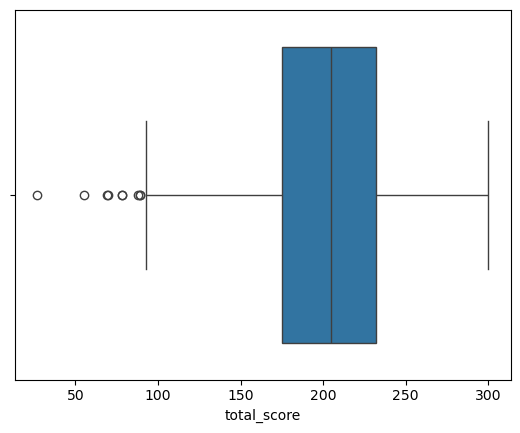

In [220]:
sns.boxplot(data=df,x='total_score')

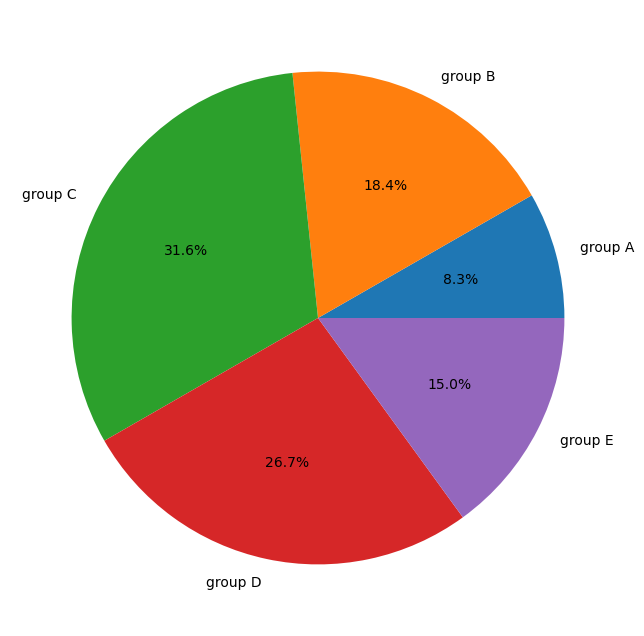

In [221]:
race_marks = df.groupby('race/ethnicity')['total_score'].sum()
plt.figure(figsize=(8, 8))
plt.pie(race_marks, 
        labels=race_marks.index, 
        autopct='%1.1f%%')
plt.show()

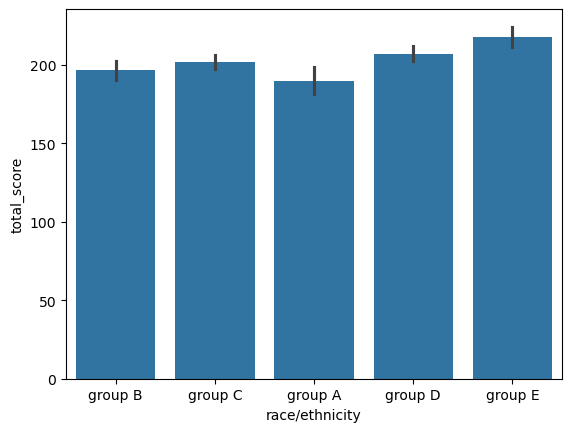

In [222]:
sns.barplot(data=df, x='race/ethnicity', y='total_score')
plt.show()


AttributeError: module 'matplotlib.pyplot' has no attribute 'Scatterplot'

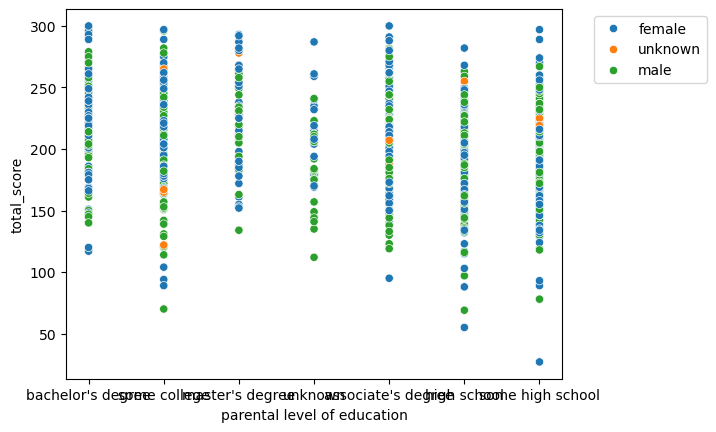

In [275]:
sns.scatterplot(data=df, y='total_score',x='parental level of education',hue='gender')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [224]:
df[['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score', 'total_score']]

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total_score
1,female,group B,bachelor's degree,standard,none,72.0,72.0,74.0,218.0
2,female,group C,some college,standard,completed,66.0,90.0,88.0,244.0
3,unknown,group B,master's degree,standard,none,90.0,95.0,93.0,278.0
4,male,group A,unknown,free/reduced,none,47.0,57.0,44.0,148.0
5,male,group C,some college,standard,none,76.0,78.0,75.0,229.0
...,...,...,...,...,...,...,...,...,...
996,female,group E,master's degree,standard,completed,88.0,99.0,95.0,282.0
997,male,group C,high school,free/reduced,none,62.0,70.0,55.0,187.0
998,female,group C,high school,free/reduced,completed,59.0,71.0,65.0,195.0
999,female,group D,some college,standard,completed,66.0,78.0,77.0,221.0


In [225]:
x=df.drop(['math score', 'reading score',
       'writing score','total_score'],axis=1)
y=df['total_score']

In [226]:
x1=pd.get_dummies(x)
x1

,gender_female,gender_male,gender_unknown,race/ethnicity_group A,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,parental level of education_associate's degree,parental level of education_bachelor's degree,parental level of education_high school,parental level of education_master's degree,parental level of education_some college,parental level of education_some high school,parental level of education_unknown,lunch_free/reduced,lunch_standard,test preparation course_completed,test preparation course_none
1,True,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,True,False,True
2,True,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,True,True,False
3,False,False,True,False,True,False,False,False,False,False,False,True,False,False,False,False,True,False,True
4,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,True,False,False,True
5,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
996,True,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,True,True,False
997,False,True,False,False,False,True,False,False,False,False,True,False,False,False,False,True,False,False,True
998,True,False,False,False,False,True,False,False,False,False,True,False,False,False,False,True,False,True,False
999,True,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,True,True,False


In [227]:
x_train,x_test,y_train,y_test = train_test_split(x1,y,train_size=0.80,random_state=0)

In [228]:
lr=LinearRegression()

In [229]:
lr.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [230]:
y_pred = lr.predict(x_test)

In [231]:
r2 = r2_score(y_test,y_pred)
r2*100

17.84843863827278

In [232]:
mae = mean_absolute_error(y_test,y_pred)
mae

30.345419527439343

In [233]:
mse = mean_squared_error(y_test,y_pred)
mse

1418.1967803107354

In [252]:
rmse = root_mean_squared_error(y_test,y_pred)
rmse

37.658953521184515

In [253]:
mape = mean_absolute_percentage_error(y_test,y_pred)
mape

0.17121116831713554

In [234]:
l1= Lasso()

In [235]:
l1.fit(x_test,y_test)

,alpha,1.0
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [236]:
y_pred_l1 = l1.predict(x_test)

In [237]:
r2_l1 = r2_score(y_test,y_pred_l1)
r2_l1*100

18.639941292153484

In [238]:
mae_l1 = mean_absolute_error(y_test,y_pred_l1)
mae_l1

30.04584064450095

In [239]:
mse_l1 = mean_squared_error(y_test,y_pred_l1)
mse_l1

1404.5329314838282

In [254]:
rmse_l1 = root_mean_squared_error(y_test,y_pred)
rmse_l1

37.658953521184515

In [255]:
mape_l1 = mean_absolute_percentage_error(y_test,y_pred)
mape_l1

0.17121116831713554

In [240]:
l2 = Ridge()

In [241]:
l2.fit(x_train,y_train)

,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [242]:
y_pred_l2 = l2.predict(x_test)

In [243]:
r2_l2 = r2_score(y_test,y_pred_l2)
r2_l2*100

17.867882547795666

In [244]:
mae_l2 = mean_absolute_error(y_test,y_pred_l2)
mae_l2

30.33509163409201

In [245]:
mse_l2 = mean_squared_error(y_test,y_pred_l2)
mse_l2

1417.8611166979576

In [256]:
rmse_l2 = root_mean_squared_error(y_test,y_pred_l2)
rmse_l2

37.65449663317726

In [257]:
mape_l2 = mean_absolute_percentage_error(y_test,y_pred_l2)
mape_l2

0.17117713235576196

In [246]:
l3 = ElasticNet()

In [247]:
l3.fit(x_train,y_train)

,alpha,1.0
,l1_ratio,0.5
,fit_intercept,True
,precompute,False
,max_iter,1000
,copy_X,True
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [248]:
y_pred_l3 = l3.predict(x_test)

In [249]:
r3_l2 = r2_score(y_test,y_pred_l3)
r3_l2*100

11.018761757516016

In [250]:
mae_l3 = mean_absolute_error(y_test,y_pred_l3)
mae_l3

30.759101888624706

In [251]:
mse_l3 = mean_squared_error(y_test,y_pred_l3)
mse_l3

1536.0986874966934

In [258]:
rmse_l3 = root_mean_squared_error(y_test,y_pred_l3)
rmse_l3

39.19309489561514

In [261]:
mape_l3 = mean_absolute_percentage_error(y_test,y_pred_l3)
mape_l3

0.17642513039648214